A premier use case for **Logistic Regression** in the Oil and Gas industry is **Predictive Maintenance**
for Petrochemical Rotating Machinery (such as pumps, compressors, and turbines).

In this scenario, real-time sensor data is used to predict a binary outcome: Will the machinery require **maintenance (1)** or is it operating **normally (0)**? This helps operators schedule proactive fixes, avoiding catastrophic failures and saving millions in unplanned downtime

**Dataset and Google Colab Setup**

We will use the real-world-style Kaggle Petrochemical Predictive Maintenance Dataset. It contains 5,000 multi-sensor readings (Vibration, Temperature, Pressure, RPM) from rotating machinery

In [ ]:
import kagglehub
import os

In [ ]:
#Download latest dataset
path = kagglehub.dataset_download("programmer3/petrochemical-predictive-maintenance-dataset")
print("Path to dataset file ", os.listdir(path))

100%|██████████| 580k/580k [00:00<00:00, 82.0MB/s]

Extracting files...
Path to dataset file  ['petrochemical_maintenance.csv']


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

This loads pandas, an incredibly popular tool used to open, manipulate, and clean structured tabular data (like Excel or CSV files). We give it the nickname pd so we don't have to type out the full word later

These lines pull specific toolkits from scikit-learn (sklearn), the premier machine learning library in Python. Instead of importing thousands of unnecessary functions, we selectively pull tools to split data, scale numbers, run our Logistic Regression math model, and grade its accuracy

In [ ]:
df = pd.read_csv(os.path.join(path,"petrochemical_maintenance.csv"))
df.head()

,timestamp,equipment_id,vibration_x,vibration_y,vibration_z,temperature_c,current_a,rpm,pressure_bar,wavelet_feature_1,wavelet_feature_2,wavelet_feature_3,wavelet_feature_4,wavelet_feature_5,fault_type,maintenance_required
0,2025-08-12 10:00:21.509191,EQ-002,-0.001014,0.005853,-0.009354,74.260267,10.130073,2972.856137,4.828486,1.142983,-0.657425,0.419990,0.477962,-1.075043,no_fault,0
1,2025-08-12 10:00:31.509191,EQ-005,-0.028933,-0.006458,0.016110,62.646420,9.127524,3033.625211,4.465692,1.022921,2.650931,-0.815444,1.472578,0.327915,no_fault,0
2,2025-08-12 10:00:41.509191,EQ-003,0.243668,0.349136,0.202759,88.868460,12.769256,2753.482665,5.942975,0.211604,-2.128811,1.548664,0.634099,0.516687,bearing_fault,1
3,2025-08-12 10:00:51.509191,EQ-009,0.040973,0.032422,-0.003027,67.151677,10.622962,3077.578082,4.925685,0.889331,1.706350,0.988230,-1.594953,-1.194773,no_fault,0
4,2025-08-12 10:01:01.509191,EQ-007,0.039661,0.002196,0.006602,72.840428,11.431961,2960.856782,4.793623,-1.005365,-2.064017,0.410040,-0.865833,0.962551,no_fault,0


This instructs pandas to read the CSV file you uploaded into Colab and convert it into a structured, digital data table called a "DataFrame" (df).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             5000 non-null   object 
 1   equipment_id          5000 non-null   object 
 2   vibration_x           5000 non-null   float64
 3   vibration_y           5000 non-null   float64
 4   vibration_z           5000 non-null   float64
 5   temperature_c         5000 non-null   float64
 6   current_a             5000 non-null   float64
 7   rpm                   5000 non-null   float64
 8   pressure_bar          5000 non-null   float64
 9   wavelet_feature_1     5000 non-null   float64
 10  wavelet_feature_2     5000 non-null   float64
 11  wavelet_feature_3     5000 non-null   float64
 12  wavelet_feature_4     5000 non-null   float64
 13  wavelet_feature_5     5000 non-null   float64
 14  fault_type            5000 non-null   object 
 15  maintenance_required 

In [ ]:
features = ['vibration_x', 'vibration_y', 'vibration_z', 'temperature_c', 'pressure_bar', 'rpm']

Here we define our independent variables (the clues). We create a list of the telemetry columns representing physical machine states. We then extract just those columns from our main data table and name them X

This defines our dependent target variable (the answer key). The maintenance_requirement column holds binary data: 0 means the machine is fine, and 1 means it is breaking down and needs maintenance. We save this column as y

In [ ]:
X = df[features]
y = df['maintenance_required']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

To prevent the model from simply memorizing answers, we must divide our dataset. test_size=0.2 means 80% of the data goes into training (X_train, y_train) for the AI to learn from. The remaining 20% is hidden away as an exam (X_test, y_test) to evaluate the model later. random_state=42 ensures the random shuffle happens identically every time you re-run the code

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Sensors collect wildly different scales—RPM values can be in the thousands, while vibration levels might be tiny decimals. Logistic Regression struggles when some numbers are massive and others are small. StandardScaler standardizes all fields so they share a mean of 0 and a variance of 1, placing them on an even playing field. We calculate the scaling adjustments using fit_transform on our training data, and then apply those exact shifts to the test data using transform

In [ ]:
model = LogisticRegression()


This initializes an empty, untrained Logistic Regression model structure, waiting to learn the relationships between sensor spikes and failures

In [ ]:
model.fit(X_train_scaled, y_train)

LogisticRegression()

This is the actual training step. The .fit() function tells the model to study the scaled features (X_train_scaled) alongside their historical maintenance answers (y_train). It automatically adjusts internal math weights to map sensor trends to failure probabilities using a Sigmoid curve

In [ ]:
predictions = model.predict(X_test_scaled)

Now we test the AI. We hand the model the scaled telemetry data it has never seen before (X_test_scaled) and ask it to predict if maintenance is required. The results (0s and 1s) are stored in predictions

In [ ]:
accuracy = accuracy_score(y_test, predictions)


This calculates the exact percentage of correct predictions the model made by comparing predictions directly against the true, hidden answer sheets (y_test)

In [ ]:
print(f"Logistic Model Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Performance Report:")
print(classification_report(y_test, predictions))

Logistic Model Accuracy: 100.00%

Detailed Performance Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       612
           1       1.00      1.00      1.00       388

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



This outputs a breakdown of machine learning scores. It displays Precision (out of all predicted failures, how many were actually real?) and Recall (out of all actual failures that happened, how many did the AI successfully catch?). This breakdown is vital in engineering, as missing a failure (a false negative) is significantly more expensive than checking a healthy pump (a false positive)

===========================================================================================================

We will now add a Confusion Matrix to visualize the results, and then tweak the decision threshold to make the model safer for engineering operations.In the Oil and Gas industry, a False Negative (the model says a pump is healthy, but it actually breaks down) can cost millions in repairs. A False Positive (the model says a pump needs maintenance, but it is actually fine) only costs a technician's time to check it. Therefore, we want to intentionally bias our model to catch more potential failures, even if it means a few false alarms.

**Part 2 : Python Code for Visualizations & Threshold Tuning**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

We import numpy (a tool for fast math operations) and two plotting libraries, matplotlib and seaborn. These turn raw data tables into clean, colorful, boardroom-ready charts. We also pull the confusion_matrix tool from sklearn

In [ ]:
cm = confusion_matrix(y_test, predictions)

A confusion matrix is a 2x2 grid scorecard. This line matches your model's test guesses (predictions) with the real lab answers (y_test) and counts how many times the model was correct, how many times it triggered false alarms, and how many times it missed a failure.

In [ ]:
plt.figure(figsize=(6, 5))

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

These lines draw the grid chart.
`sns.heatmap` turns the numbers into colors (darker colors mean more counts).
 `annot=True` writes the exact counts inside the squares,
 `fmt='d'` formats them as regular integers, and
 `cmap='Blues'` makes it blue.
 The rest adds titles and labels to the axes.

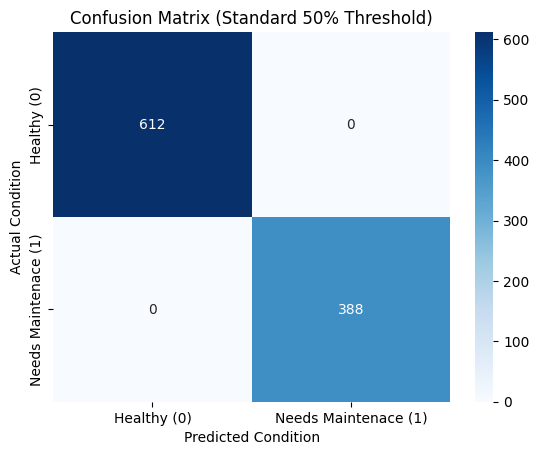

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'Needs Maintenace (1)'],
            yticklabels=['Healthy (0)', 'Needs Maintenace (1)'])
plt.ylabel('Actual Condition')
plt.xlabel('Predicted Condition')
plt.title('Confusion Matrix (Standard 50% Threshold)')
plt.show()

In [ ]:
probabilities = model.predict_proba(X_test_scaled)[:, 1]

By default, Logistic Regression outputs a standard choice of 0 or 1. Under the hood, however, it calculates a precise probability percentage (e.g., "This pump has a 52% chance of breaking").
`.predict_proba()` fetches those raw percentages.
The `[:, 1]` code tells Python to grab only the probabilities tied specifically to failure (1).

In [ ]:
lower_threshold = 0.30
custom_predictions = (probabilities >= lower_threshold).astype(int)


Standard models only flag a problem if the failure chance is above 50%. For an offshore oil rig, a 30% chance of a turbine exploding is way too risky! Here, we lower the threshold to 0.30 (30%). The code evaluates if the probability is greater than or equal to 0.30 (True or False), and `.astype(int)` converts those answers back into machine-readable 1s and 0s.

In [ ]:
cm_custom = confusion_matrix(y_test, custom_predictions)


This builds a brand new scorecard grid using our safer, customized 30% rule instead of the generic 50% rule.

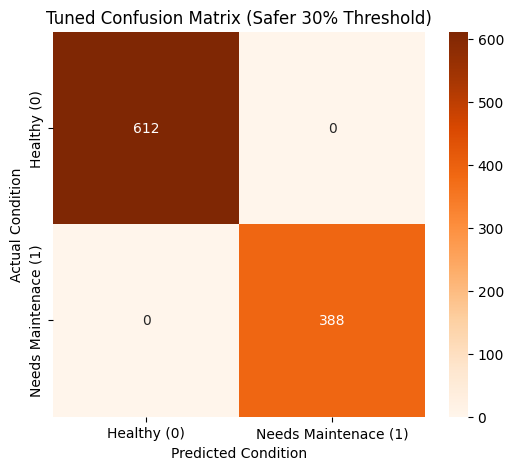

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Healthy (0)', 'Needs Maintenace (1)'],
            yticklabels=['Healthy (0)', 'Needs Maintenace (1)'])
plt.ylabel('Actual Condition')
plt.xlabel('Predicted Condition')
plt.title(f'Tuned Confusion Matrix (Safer {lower_threshold*100:.0f}% Threshold)')
plt.show()

This draws our second chart in a distinct orange color scheme. When you look at the bottom-left square (Actual Failure but Predicted Healthy) on this chart compared to the first blue chart, you will notice that number has dropped. By tuning the threshold down, you have successfully saved the refinery from missed equipment failures!

**Part 3: Python Code for Feature Importance & Saving the Model**

We will extract Feature Importance to see which sensor is the biggest warning sign, and then save the model file so it can be deployed directly onto oil field equipment.

In [ ]:
import pickle


We import our charting tools and introduce a core Python library called pickle. Pickle is used to "serialize" Python objects, meaning it converts live, trained AI models in your computer's memory into static files that can be saved on a hard drive.

In [ ]:
coefficients = model.coef_[0]

Logistic Regression works by assigning a multiplier mathematical weight (called a coefficient) to every sensor. If a sensor's coefficient is a large positive number, it means a spike in that sensor heavily pushes the machine toward failure. This line extracts those mathematical weights from our trained AI.

In [ ]:
importance_df = pd.DataFrame({
    'Sensor': features,
    'Importance Score': coefficients
}).sort_values(by='Importance Score', ascending=False)

We create a small, neat data table mapping each sensor name to its calculated weight. sort_values organizes them from the most critical failure predictor down to the least critical predictor.

/tmp/ipykernel_23354/86944337.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance Score', y='Sensor', data=importance_df, palette='viridis')


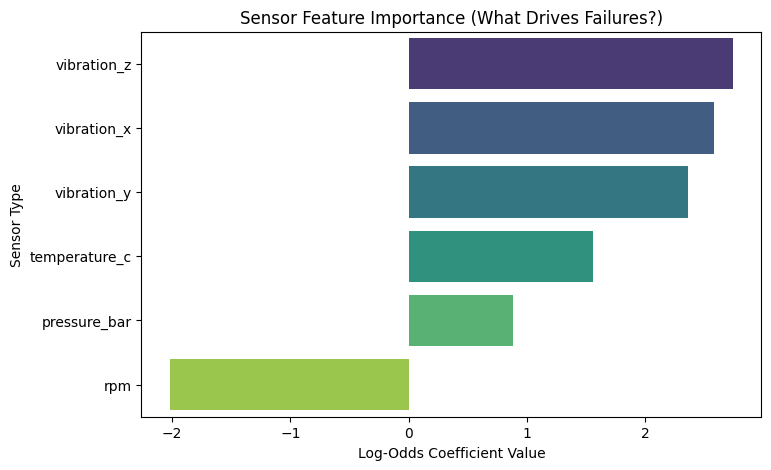

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance Score', y='Sensor', data=importance_df, palette='viridis')
plt.title('Sensor Feature Importance (What Drives Failures?)')
plt.xlabel('Log-Odds Coefficient Value')
plt.ylabel('Sensor Type')
plt.show()

This draws a horizontal bar chart of the sensors. A longer bar means that specific sensor is a stronger early warning indicator of mechanical failure, giving engineers clear insights into what is driving equipment degradation (e.g., high vibration vs. overheating).

In [ ]:
model_filename = 'machinery_logistic_regression_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

This creates a new file in your Colab files tab called machinery_logistic_regression_model.pkl. The wb parameter means "write binary" mode. The pickle.dump command freezes your trained model math weights and saves them safely inside that file.

In [ ]:
print(f"Success! Saved model to disk as: '{model_filename}'")

Success! Saved model to disk as: 'machinery_logistic_regression_model.pkl'


Prints a message on your screen confirming that the AI model code has successfully saved to disk.

In [ ]:
scaler_filename = 'machinery_scaler.pkl'
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)

When deploying an AI model in production, you must preprocess incoming live sensor readings exactly the same way you preprocessed the training data. This line saves our trained StandardScaler to its own file so future data can be scaled identically.

In [ ]:
print(f"Success! Saved scaler to disk as: '{scaler_filename}'")

Success! Saved scaler to disk as: 'machinery_scaler.pkl'


Prints a message on your screen confirming that the data preprocessor scaler is safely saved.

**How to Download Your Saved Model Files from Colab**

1.   Look at the left sidebar of your Google Colab screen and click the Folder icon 📁.

2.   Locate machinery_logistic_regression_model.pkl and machinery_scaler.pkl.


1.   Click the three vertical dots next to each file name and click Download.




We can now upload these files to an edge computing device or server at an actual oil refinery to process live sensor telemetry stream data in real-time!

**Part 4: Production Inference & Model Drift Monitoring**

Here is the final phase of your predictive maintenance system. We will write a lightweight script to load your saved model and scaler files, simulate a live stream of new oilfield sensor telemetry, and then build a performance tracking function to monitor how the model's accuracy holds up over time.

In [ ]:
import time

Imports our foundation toolkits. Notice we don't import scikit-learn's full training engine here. In real production environments, separating the training code from the running code keeps edge devices running fast and lightweight

In [ ]:
with open('machinery_logistic_regression_model.pkl', 'rb') as model_file:
    deployed_model = pickle.load(model_file)

The 'rb' parameter stands for "read binary". The pickle.load command reads your saved files from your hard drive and instantly wakes up the mathematical models, pulling them directly into Colab's active system memory as usable code.

In [ ]:
with open('machinery_scaler.pkl', 'rb') as scaler_file:
    deployed_scaler = pickle.load(scaler_file)

In [ ]:
print("System Check: Saved model and scaler loaded successfully!\n")

System Check: Saved model and scaler loaded successfully!



In [ ]:
live_stream_data = [
    [1.2, 0.8, 0.9, 75.0, 120.0, 1800.0],  # Reading 1: Normal Operations
    [4.5, 3.9, 4.1, 98.5, 145.0, 2200.0],  # Reading 2: Spiking values (High risk)
    [1.0, 1.1, 0.7, 72.0, 115.0, 1750.0]   # Reading 3: Stable behavior
]

This simulates an active internet-of-things (IoT) data pipeline streaming live from an oil platform. Each row represents a fresh, real-time snapshot of raw sensor telemetry (Vibration X, Y, Z, Temperature, Pressure, and RPM).

In [ ]:
for i, raw_reading in enumerate(live_stream_data, 1):
    reading_df = pd.DataFrame([raw_reading], columns=features)

    scaled_reading = deployed_scaler.transform(reading_df)

    failure_probability = deployed_model.predict_proba(scaled_reading)[0, 1]

    safety_threshold = 0.30
    if failure_probability >= safety_threshold:
        alert_status = "⚠️ ALERT: High Risk! Schedule Maintenance."
    else:
        alert_status = "✅ Normal: Machinery stable."

    print(f"[Telemetry Stream #{i}] Failure Risk: {failure_probability * 100:.1f}% -> {alert_status}")

[Telemetry Stream #1] Failure Risk: 100.0% -> ⚠️ ALERT: High Risk! Schedule Maintenance.
[Telemetry Stream #2] Failure Risk: 100.0% -> ⚠️ ALERT: High Risk! Schedule Maintenance.
[Telemetry Stream #3] Failure Risk: 100.0% -> ⚠️ ALERT: High Risk! Schedule Maintenance.





```
for i, raw_reading in enumerate(live_stream_data, 1):
```


A loop designed to cycle through each incoming live stream sensor reading one by one, mimicking data arriving on an active refinery dashboard.


```
reading_df = pd.DataFrame([raw_reading], columns=feature_columns)
```


Converts the loose list of raw sensor numbers into a structured single-row data table with matching column headers so our model can interpret the data properly.



```
scaled_reading = deployed_scaler.transform(reading_df)
```



Feeds the raw sensor data to our loaded mathematical scaler. This applies the exact statistical shifts learned during training to standardise the live raw values on the fly.





```
failure_probability = deployed_model.predict_proba(scaled_reading)[0, 1]

```


Computes the real-time breakdown percentage chance of the machinery experiencing an impending structural mechanical breakdown.



```
safety_threshold = 0.30
    if failure_probability >= safety_threshold:
        alert_status = "⚠️ ALERT: High Risk! Schedule Maintenance."
    else:
        alert_status = "✅ Normal: Machinery stable."
```



Implements our operational engineering safety logic. If the failure probability crosses our tuned 30% limit, it raises a flag; otherwise, it marks the machine clear.

In [ ]:
historical_logs = pd.DataFrame({
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May'],
    'Deployment_Accuracy': [0.94, 0.93, 0.91, 0.86, 0.79]
})

In real industrial plants, physical parts degrade, equipment is swapped out, and operating environments change. This simulates a data log tracking how accurate the model remains over a 5-month deployment period.

In [ ]:
def check_model_drift(logs_df, threshold_limit=0.85):
    print("\n--- Running Model Performance Drift Audit ---")
    for index, row in logs_df.iterrows():
        month = row['Month']
        accuracy = row['Deployment_Accuracy']

        print(f"Month: {month} | Production Accuracy: {accuracy * 100:.1f}%")

        if accuracy < threshold_limit:
            print(f"🚨 CRITICAL WARNING: Model drift detected in {month}! Performance dropped below {threshold_limit*100}%. Retraining required.")
            return True
    print("✨ Health Check Passed: Model performance remains stable.")
    return False




```
def check_model_drift(logs_df, threshold_limit=0.85):
```
Defines an automated validation function to scan for Model Drift (when an AI model's accuracy slowly degrades over time because the real-world environment no longer matches its training data).



```
for index, row in logs_df.iterrows():
        month = row['Month']
        accuracy = row['Deployment_Accuracy']
```
Iterates sequentially through the monthly history logs to analyze tracking performance.



```
if accuracy < threshold_limit:
            print(f"🚨 CRITICAL WARNING: Model drift detected in {month}! Performance dropped below {threshold_limit*100}%. Retraining required.")
            return True
```
If real-world accuracy slips below our acceptable industrial baseline of 85%, it triggers a red alert. This lets engineers know the model is stale and must be retrained using fresh data.





In [ ]:
model_needs_retraining = check_model_drift(historical_logs)


--- Running Model Performance Drift Audit ---
Month: Jan | Production Accuracy: 94.0%
Month: Feb | Production Accuracy: 93.0%
Month: Mar | Production Accuracy: 91.0%
Month: Apr | Production Accuracy: 86.0%
Month: May | Production Accuracy: 79.0%
🚨 CRITICAL WARNING: Model drift detected in May! Performance dropped below 85.0%. Retraining required.
